<a href="https://colab.research.google.com/github/NicoPerotto/challenge2-data-science-LATAM-Parte-2/blob/main/TelecomX_part2_LATAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#🎯Objetivo


Desarrollar modelos predictivos capaces de prever qué clientes tienen mayor probabilidad de cancelar sus servicios.

#⬇️Importación y procedimientos


In [91]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler
from imblearn.over_sampling import SMOTE


from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import KFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

import seaborn as sns

###Procedimiento para mejorar la visualziacion de datos


In [92]:
def info(df):
    print(f"{'#':<3} {'Columna':<20} {'Tipo':<12} {'Indet.':<10} {'Valores Únicos / Ejemplo'}")
    print("-" * 90)

    for i, col in enumerate(df.columns):
        dtype = str(df[col].dtype)

        # 1. Conteo de vacíos (usamos apply para evitar errores de tipo)
        # Esto cuenta nulos reales, espacios y strings vacíos de forma segura
        vacios = df[col].apply(lambda x: x in ['', ' ', np.nan, None]).sum()

        try:
            # 2. Intentamos sacar valores únicos
            valores = df[col].unique().tolist()

            if len(valores) < 10:
                resumen = f"{valores}"
            else:
                resumen = f"{len(valores)} valores diferentes"
        except TypeError:
            # 3. Si falla por tener diccionarios/listas, damos un resumen alternativo
            resumen = "[Contiene diccionarios o listas]"

        print(f"{i:<3} {col:<20} {dtype:<12} {vacios:<10} {resumen}")

    print("-" * 90)
    filas, columnas = df.shape
    memoria = df.memory_usage(deep=True).sum() / (1024 ** 2) # Convertir a MB

    print(f"Tamaño total: {filas} filas y {columnas} columnas")

In [93]:
def model_report(name, model, X_test, y_test):
    y_pred = model.predict(X_test)

    # Intentamos extraer importancias de varias formas posibles
    importances = None
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
    elif hasattr(model, 'best_estimator_') and hasattr(model.best_estimator_, 'feature_importances_'):
        importances = model.best_estimator_.feature_importances_

    print(f"\n{'='*40}\n REPORTE: {name}\n{'='*40}")
    print(classification_report(y_test, y_pred))

    # Si encontramos importancias, preparamos 2 columnas
    if importances is not None:
        fig, ax = plt.subplots(1, 2, figsize=(15, 6), gridspec_kw={'width_ratios': [1, 2]})
        ax_matrix = ax[0]
        ax_imp = ax[1]
    else:
        fig, ax_matrix = plt.subplots(1, 1, figsize=(6, 5))
        ax_imp = None

    # --- Matriz de Confusión (Siempre cuadrada) ---
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', ax=ax_matrix, cbar=False)
    ax_matrix.set_title("Matriz de Confusión")
    ax_matrix.set_xlabel("Predicción")
    ax_matrix.set_ylabel("Real")

    # --- Importancia de Variables ---
    if ax_imp is not None:
        feat_imp = pd.Series(importances, index=X_test.columns).sort_values(ascending=True)
        feat_imp.plot(kind='barh', color=plt.cm.viridis(feat_imp / feat_imp.max()), ax=ax_imp)
        ax_imp.set_title(f"Importancia de Variables - {name}")
        ax_imp.set_xlabel("Poder Predictivo")
        ax_imp.grid(axis='x', linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

#📌 Extracción


In [94]:
url = 'https://raw.githubusercontent.com/NicoPerotto/challenge2-data-science-LATAM/refs/heads/main/dataFrame.csv'
dataFrame = pd.read_csv(url)

In [95]:
dataFrame.head()

,Unnamed: 0,evasión,genero,adulto_mayor,tiene_pareja,dependientes,antiguedad,servicio_telefónico,multiples_lineas,internet,...,soporte_tecnico,streaming_TV,streaming_peliculas,tipo_de_contrato,factura_digital,metodo_de_pago,cargo_mensual,cargo_total,cargo_diario,cantidad_servicios
0,0,0,Female,0,1,1,9,1,0,DSL,...,1,1,0,One year,1,Mailed check,65.6,593.30,2.186667,5
1,1,0,Male,0,0,0,9,1,1,DSL,...,0,0,1,Month-to-month,0,Mailed check,59.9,542.40,1.996667,4
2,2,1,Male,0,0,0,4,1,0,Fiber optic,...,0,0,0,Month-to-month,1,Electronic check,73.9,280.85,2.463333,3
3,3,1,Male,1,1,0,13,1,0,Fiber optic,...,0,1,1,Month-to-month,1,Electronic check,98.0,1237.85,3.266667,6
4,4,1,Female,1,1,0,3,1,0,Fiber optic,...,1,1,0,Month-to-month,1,Mailed check,83.9,267.40,2.796667,4


In [96]:
dataFrame = dataFrame.drop(columns=['Unnamed: 0'])
dataFrame.rename(columns={'evasión': 'cancelacion'}, inplace=True)

In [97]:
info(dataFrame)

#   Columna              Tipo         Indet.     Valores Únicos / Ejemplo
------------------------------------------------------------------------------------------
0   cancelacion          int64        0          [0, 1]
1   genero               object       0          ['Female', 'Male']
2   adulto_mayor         int64        0          [0, 1]
3   tiene_pareja         int64        0          [1, 0]
4   dependientes         int64        0          [1, 0]
5   antiguedad           int64        0          73 valores diferentes
6   servicio_telefónico  int64        0          [1, 0]
7   multiples_lineas     int64        0          [0, 1]
8   internet             object       0          ['DSL', 'Fiber optic', 'No']
9   seguridad_online     int64        0          [0, 1]
10  respaldo_en_la_nube  int64        0          [1, 0]
11  proteccion_de_dispositivo int64        0          [0, 1]
12  soporte_tecnico      int64        0          [1, 0]
13  streaming_TV         int64        0          [1, 

#🛠️ Preparación de los Datos


##Verificación correlación entre posibles columnas redundantes


Parejas de variables con mayor correlación:
cargo_mensual         cargo_diario            1.000000
cantidad_servicios    cargo_mensual           0.851380
                      cargo_diario            0.851380
cargo_total           antiguedad              0.826178
cargo_mensual         internet_Fiber optic    0.787066
internet_Fiber optic  cargo_diario            0.787066
cargo_total           cantidad_servicios      0.776431
internet_No           cargo_diario            0.763557
streaming_peliculas   cantidad_servicios      0.678958
cantidad_servicios    streaming_TV            0.676035
dtype: float64


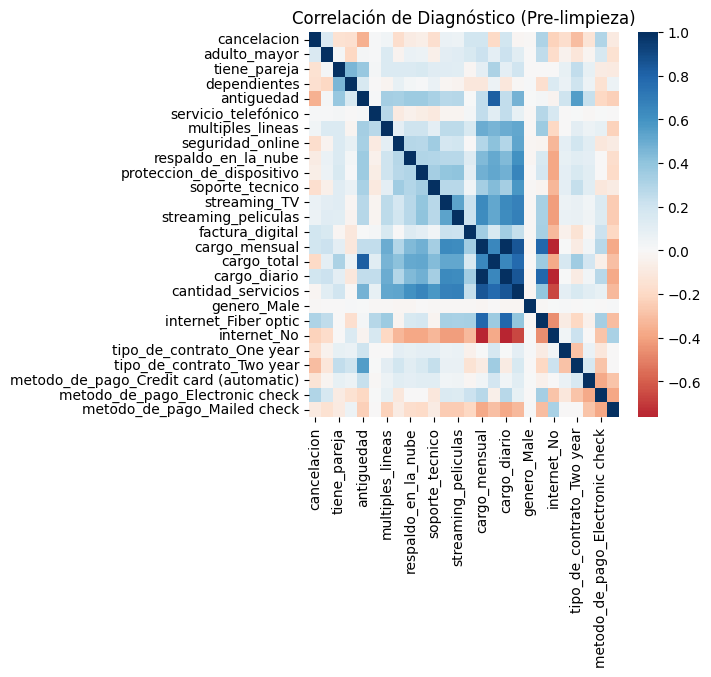

In [98]:
# 1. Creamos una copia temporal para análisis
df_encoded = pd.get_dummies(dataFrame, columns=['genero', 'internet', 'tipo_de_contrato', 'metodo_de_pago'], drop_first=True)

# 2. Calculamos la correlación
corr = df_encoded.corr()

# 3. Filtramos para ver qué columnas están MUY relacionadas (más de 0.9)
# Esto dirá qué columnas sobran de forma objetiva
highly_correlated = corr.abs().unstack().sort_values(ascending=False)
highly_correlated = highly_correlated[highly_correlated < 1].drop_duplicates()

print("Parejas de variables con mayor correlación:")
print(highly_correlated.head(10))

# 4. Graficamos el Heatmap
plt.figure(figsize=(5, 5))
sns.heatmap(corr, annot=False, cmap='RdBu', center=0)
plt.title("Correlación de Diagnóstico (Pre-limpieza)")
plt.show()


**Interpretación:**
*   La variable cargo_diario es un duplicado matemático exacto de cargo_mensual.
*   cargo_mensual y cantidad_servicios están altamente correlacionadas (0.85).
*   El Heatmap muestra una zona muy oscura (alta correlación) en el bloque de servicios adicionales.
*   La alta correlación entre antiguedad y cargo_total (0.82)
*   Genero_Male no tiene impacto visual en el heatmap respecto al target.







###Eliminación por Correlación

In [99]:
cols_a_eliminar = ['cargo_diario','cantidad_servicios','cargo_total','genero_Male']
df_encoded = df_encoded.drop(columns=cols_a_eliminar,errors='ignore')

##Verificación por Multicolinealidad

In [100]:
X = df_encoded.drop(columns=['cancelacion'])
X_const = sm.add_constant(X)
X_const = X_const.astype(float)
vif_data = pd.DataFrame()
vif_data["feature"] = X_const.columns
vif_data["VIF"] = [variance_inflation_factor(X_const.values, i) for i in range(X_const.shape[1])]

In [101]:
display(vif_data.sort_values(by='VIF', ascending=False))

,feature,VIF
14,cargo_mensual,862.547247
0,const,616.168129
15,internet_Fiber optic,148.240980
16,internet_No,104.124894
5,servicio_telefónico,34.855149
12,streaming_peliculas,24.101173
11,streaming_TV,24.049655
6,multiples_lineas,7.269808
9,proteccion_de_dispositivo,6.903647
8,respaldo_en_la_nube,6.746616


**Interpretación:**
*   Cargo_mensual tiene un VIF extremo (>800).
*   Redundancia estructural en categorías de internet (Fiber optic vs No).




###Eliminación por Multicolinealidad

In [102]:
# Eliminamos las últimas columnas de alto VIF para dejar el modelo estable
ultimas_cols_vif = ['cargo_mensual', 'internet_No']
df_encoded = df_encoded.drop(columns=ultimas_cols_vif, errors='ignore')
df_encoded = df_encoded.astype(int)
df_encoded.head()

,cancelacion,adulto_mayor,tiene_pareja,dependientes,antiguedad,servicio_telefónico,multiples_lineas,seguridad_online,respaldo_en_la_nube,proteccion_de_dispositivo,soporte_tecnico,streaming_TV,streaming_peliculas,factura_digital,internet_Fiber optic,tipo_de_contrato_One year,tipo_de_contrato_Two year,metodo_de_pago_Credit card (automatic),metodo_de_pago_Electronic check,metodo_de_pago_Mailed check
0,0,0,1,1,9,1,0,0,1,0,1,1,0,1,0,1,0,0,0,1
1,0,0,0,0,9,1,1,0,0,0,0,0,1,0,0,0,0,0,0,1
2,1,0,0,0,4,1,0,0,0,1,0,0,0,1,1,0,0,0,1,0
3,1,1,1,0,13,1,0,0,1,1,0,1,1,1,1,0,0,0,1,0
4,1,1,1,0,3,1,0,0,0,0,1,1,0,1,1,0,0,0,0,1


##Encoding

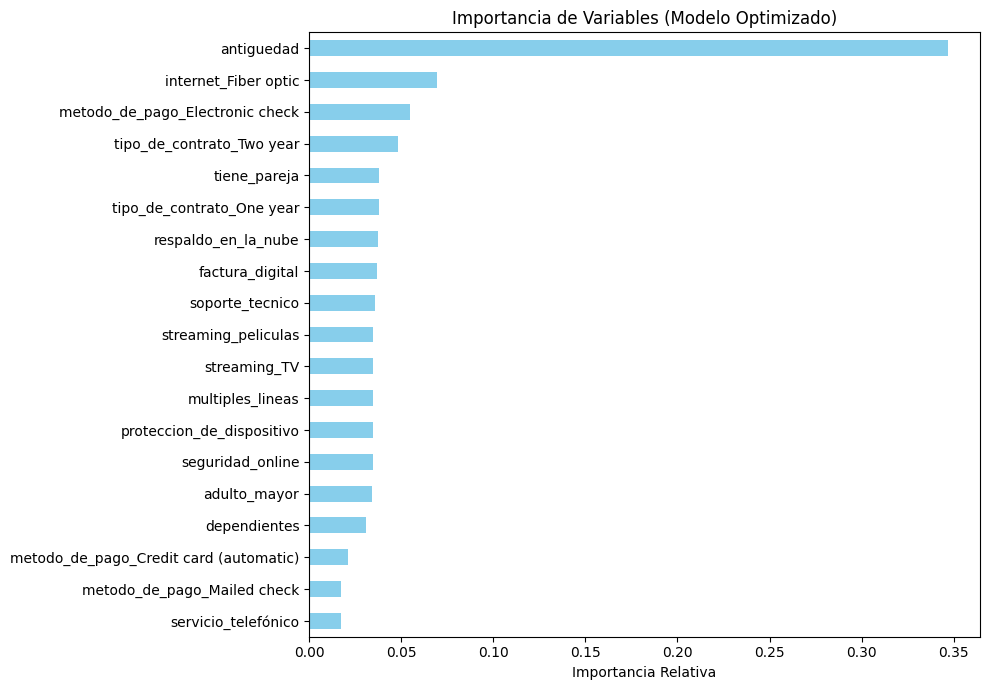

In [103]:
# 1. Separar características (X) y objetivo (y) usando tus datos procesados
X = df_encoded.drop(columns=['cancelacion'])
y = df_encoded['cancelacion']

# 2. División de datos (Recomendado para evitar overfitting)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Entrenar el modelo Random Forest
# Usamos random_state=42 para asegurar la reproducibilidad
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 4. Graficar importancia de variables
importances = pd.Series(model.feature_importances_, index=X.columns)
importances.sort_values(ascending=True).plot(
    kind='barh',
    figsize=(10, 7),
    title='Importancia de Variables (Modelo Optimizado)',
    color='skyblue'
)
plt.xlabel('Importancia Relativa')
plt.tight_layout()
plt.show()

# 5. Reporte de métricas básicas
y_pred = model.predict(X_test)


**Interpretación**


*   Antiguedad:	A menor tiempo, mayor riesgo de cancelacion.
*   internet_Fiber optic: posible problema de precio o estabilidad técnica.
*   tipo_de_contrato_Two year: los contratos largos retienen al cliente.



###Reporte de clasificación, desbalance de clases.


In [104]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.90      0.86      1036
           1       0.61      0.46      0.52       373

    accuracy                           0.78      1409
   macro avg       0.72      0.68      0.69      1409
weighted avg       0.77      0.78      0.77      1409



**Interpretación**

*   El modelo tiene un excelente recall (0.90) para los clientes que se quedan, pero solo detecta al 46% de los que efectivamente cancelan el servicio
*   Desbalance de Soporte: Tienes casi el triple de ejemplos de cancelacion 0 (1036) frente a la cancelacion 1 (373).



###**Verificación de la Proporción de Cancelación**

In [105]:
# Proporción (porcentaje)
print("\nProporción de cancelacion (%):")
print(df_encoded['cancelacion'].value_counts(normalize=True) * 100)


Proporción de cancelacion (%):
cancelacion
0    73.463013
1    26.536987
Name: proportion, dtype: float64


##**Balanceo de Clases**

In [106]:
# 1. Definir los métodos de balanceo para iterar (Modularidad)
samplers = {
    'SMOTE': SMOTE(random_state=42),
    'Random UnderSampler': RandomUnderSampler(random_state=42),
    'Random OverSampler': RandomOverSampler(random_state=42)
}

results = {}

# 2. Bucle de experimentación (Reproduce el flujo en cada técnica)
for name, sampler in samplers.items():
    # Aplicar balanceo SOLO a entrenamiento
    X_res, y_res = sampler.fit_resample(X_train, y_train)

    # Entrenar modelo
    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X_res, y_res)

    # Predecir sobre el set de prueba ORIGINAL (Clave para MLOps)
    y_pred = model.predict(X_test)

    # Guardar reporte para comparar
    results[name] = classification_report(y_test, y_pred, output_dict=True)
    print(f"--- Reporte para {name} ---")
    print(classification_report(y_test, y_pred))

--- Reporte para SMOTE ---
              precision    recall  f1-score   support

           0       0.85      0.80      0.82      1036
           1       0.52      0.60      0.56       373

    accuracy                           0.75      1409
   macro avg       0.69      0.70      0.69      1409
weighted avg       0.76      0.75      0.75      1409

--- Reporte para Random UnderSampler ---
              precision    recall  f1-score   support

           0       0.89      0.72      0.79      1036
           1       0.49      0.75      0.59       373

    accuracy                           0.73      1409
   macro avg       0.69      0.74      0.69      1409
weighted avg       0.78      0.73      0.74      1409

--- Reporte para Random OverSampler ---
              precision    recall  f1-score   support

           0       0.84      0.84      0.84      1036
           1       0.56      0.55      0.56       373

    accuracy                           0.77      1409
   macro avg       0

**interpretación**

Random UnderSampler:  Aunque tiene un F1-Score similar a SMOTE, el mayor Recall (0.75) para la clase 1, captura el 75% de las cancelaciones reales. Dado que tu F1-Score más alto (0.59), este método ha demostrado ser muy efectivo para este dataset específico.

#🎯 Correlación y Selección de Variables

##**Visualizar la matriz de correlación**

Parejas de variables con mayor correlación:
antiguedad                              tipo_de_contrato_Two year          0.558533
streaming_peliculas                     streaming_TV                       0.533094
tiene_pareja                            dependientes                       0.452676
proteccion_de_dispositivo               streaming_peliculas                0.402111
streaming_TV                            proteccion_de_dispositivo          0.390874
metodo_de_pago_Electronic check         metodo_de_pago_Mailed check        0.387372
antiguedad                              tiene_pareja                       0.379697
metodo_de_pago_Credit card (automatic)  metodo_de_pago_Electronic check    0.373322
internet_Fiber optic                    multiples_lineas                   0.366083
proteccion_de_dispositivo               antiguedad                         0.360653
dtype: float64


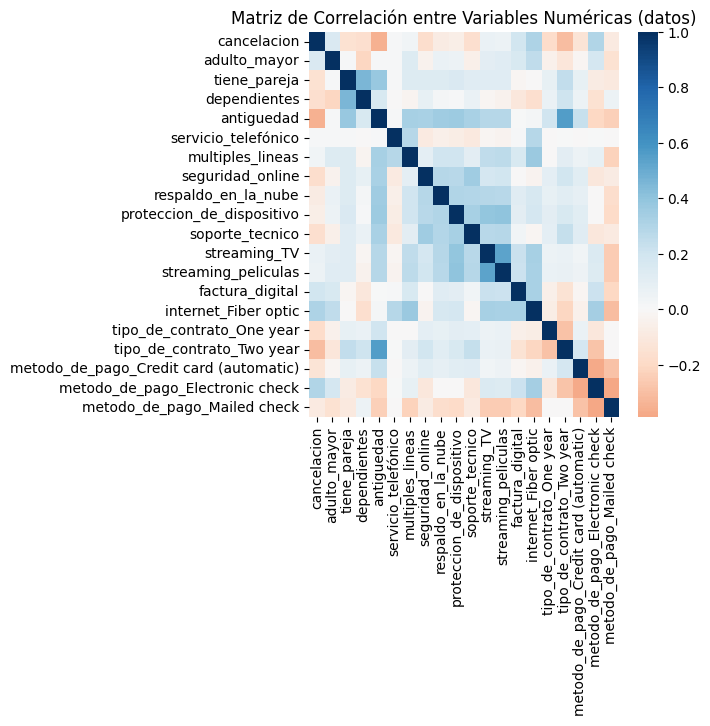

In [107]:
matriz_corr = df_encoded.corr()

highly_correlated = matriz_corr.abs().unstack().sort_values(ascending=False)
highly_correlated = highly_correlated[highly_correlated < 1].drop_duplicates()

print("Parejas de variables con mayor correlación:")
print(highly_correlated.head(10))

# Visualizar la matriz de correlación
plt.figure(figsize=(5, 5))
sns.heatmap(matriz_corr, annot=False, cmap='RdBu', center=0)
plt.title("Matriz de Correlación entre Variables Numéricas (datos)")
plt.show()

**Confiramción de la estabilidad del modelo**

-La correlación más alta es de 0.55 (entre antiguedad y tipo_de_contrato_Two year), ambas variables conviven con un VIF bajo (2.75 y 2.43 respectivamente) y pueden aportar valor predictivo independiente al modelo.

##**Análisis Dirigido**

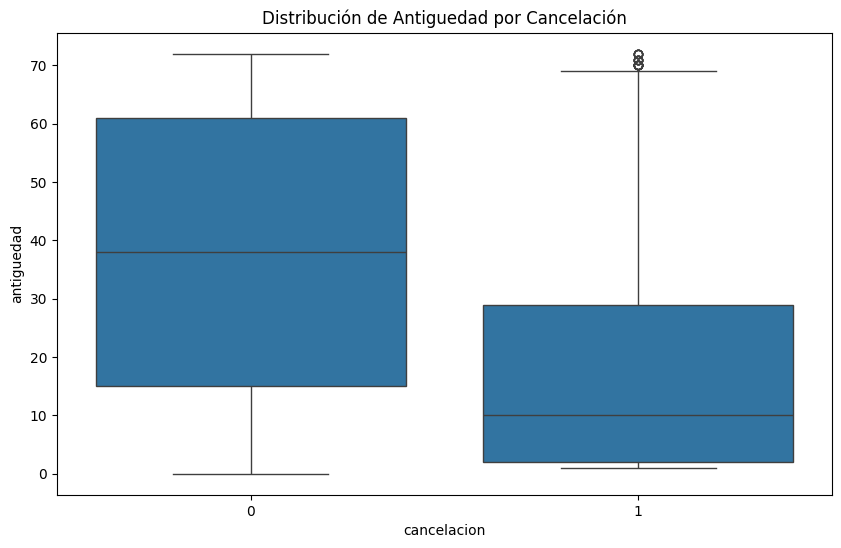

In [108]:
# 1. Tiempo de antiguedad vs Cancelación (Boxplot)
plt.figure(figsize=(10, 6))
sns.boxplot(x='cancelacion', y='antiguedad', data=dataFrame)
plt.title('Distribución de Antiguedad por Cancelación')
plt.show()


Patrón de Fuga: La mediana de los clientes que cancelan es extremadamente baja, rondando los 10 meses, comparada con los casi 40 meses de los que se quedan.

Zona Crítica: El 75% de las cancelaciones ocurren antes de los 30 meses de antigüedad.

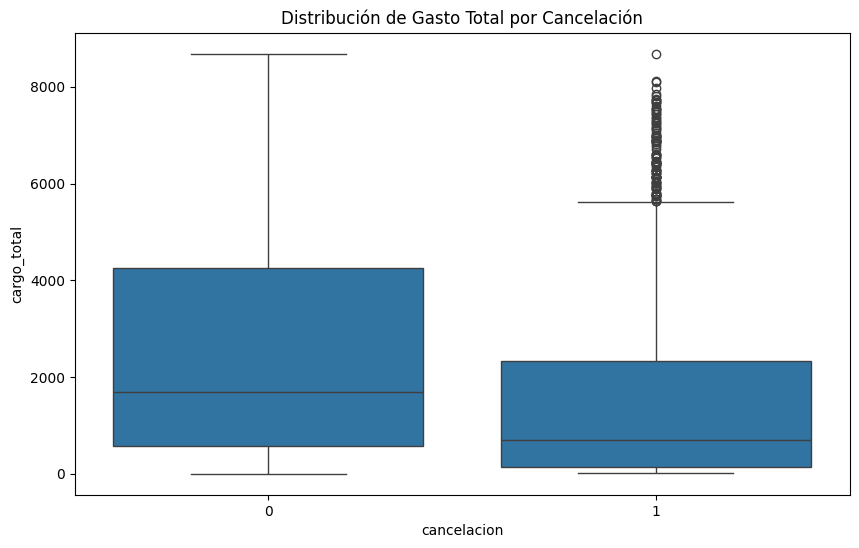

In [109]:
# 2. Gasto Total vs Cancelación (Boxplot)
plt.figure(figsize=(10, 6))
sns.boxplot(x='cancelacion', y='cargo_total', data=dataFrame)
plt.title('Distribución de Gasto Total por Cancelación')
plt.show()

Los clientes que cancelan tienden a tener un cargo_total acumulado mucho menor.


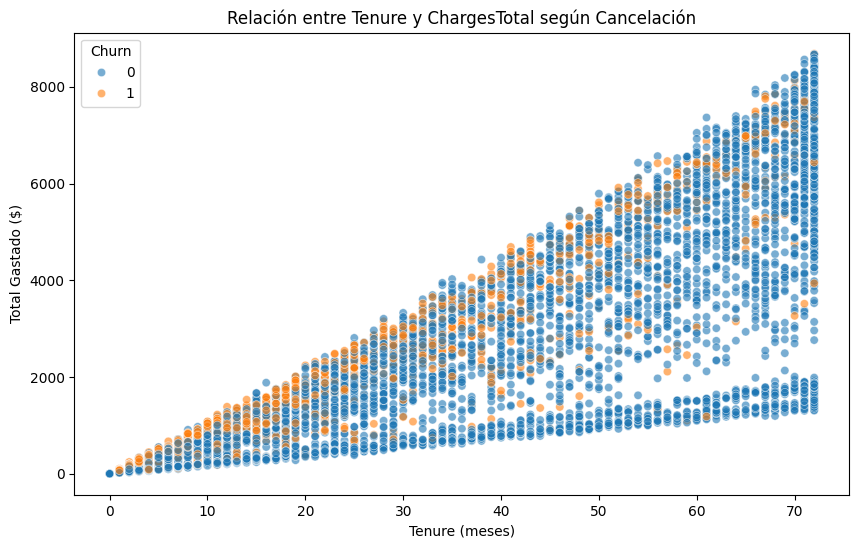

In [110]:
# 3. Scatter plot (Tenure vs ChargesTotal coloreado por Churn)
plt.figure(figsize=(10, 6))
sns.scatterplot(x='antiguedad', y='cargo_total', hue='cancelacion', data=dataFrame, alpha=0.6)
plt.title('Relación entre Tenure y ChargesTotal según Cancelación')
plt.xlabel('Tenure (meses)')
plt.ylabel('Total Gastado ($)')
plt.legend(title='Churn')
plt.show()

La forma de "abanico" ascendente muestra una correlación lineal casi perfecta entre la antigüedad y el gasto total.

#🤖 Modelado Predictivo

##Separación de Datos

In [111]:
# 1. Preparación y División
X = df_encoded.drop(columns=['cancelacion'])
y = df_encoded['cancelacion']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Aplicamos Random UnderSampler (RUS)
rus = RandomUnderSampler(random_state=42)
X_train_res, y_train_res = rus.fit_resample(X_train, y_train)

# Verificamos tamaños
print(f"Tamaño de entrenamiento: {X_train_res.shape[0]} filas")
print(f"Tamaño de prueba: {X_test.shape[0]} filas")


Tamaño de entrenamiento: 2992 filas
Tamaño de prueba: 1409 filas


#Creación de Modelos

### Normalización

In [112]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

###Regresión Logarítmica


 REPORTE: Regresión Logística
              precision    recall  f1-score   support

           0       0.90      0.73      0.81      1036
           1       0.51      0.78      0.62       373

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.76      1409



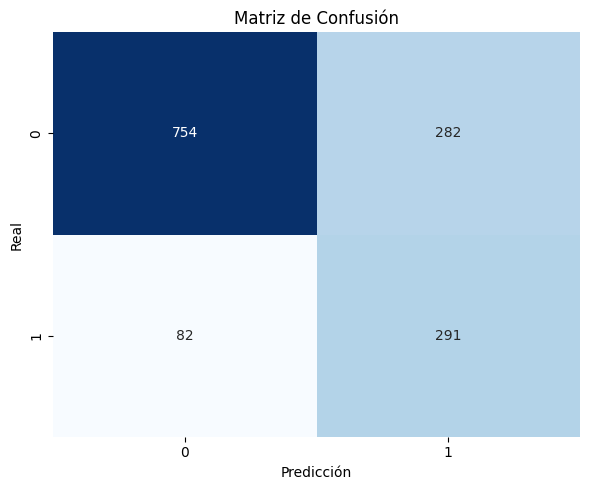

In [113]:
log_model = LogisticRegression(random_state=42).fit(X_train_scaled, y_train_res)
model_report("Regresión Logística", log_model, X_test_scaled, y_test)

###K-Nearest Neighbors (KNN)


 REPORTE: KNN
              precision    recall  f1-score   support

           0       0.86      0.68      0.76      1036
           1       0.44      0.70      0.54       373

    accuracy                           0.69      1409
   macro avg       0.65      0.69      0.65      1409
weighted avg       0.75      0.69      0.71      1409



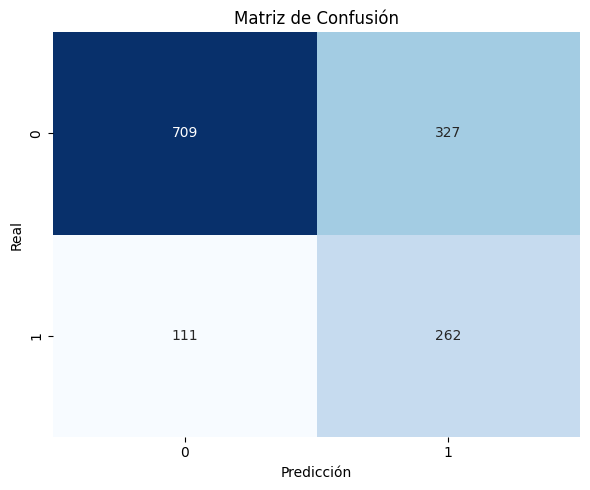

In [114]:
knn_model = KNeighborsClassifier(n_neighbors=5).fit(X_train_scaled, y_train_res)
model_report("KNN", knn_model, X_test_scaled, y_test)

###Árbol de Decisión


 REPORTE: Árbol de Decisión
              precision    recall  f1-score   support

           0       0.85      0.69      0.76      1036
           1       0.44      0.67      0.53       373

    accuracy                           0.68      1409
   macro avg       0.64      0.68      0.64      1409
weighted avg       0.74      0.68      0.70      1409



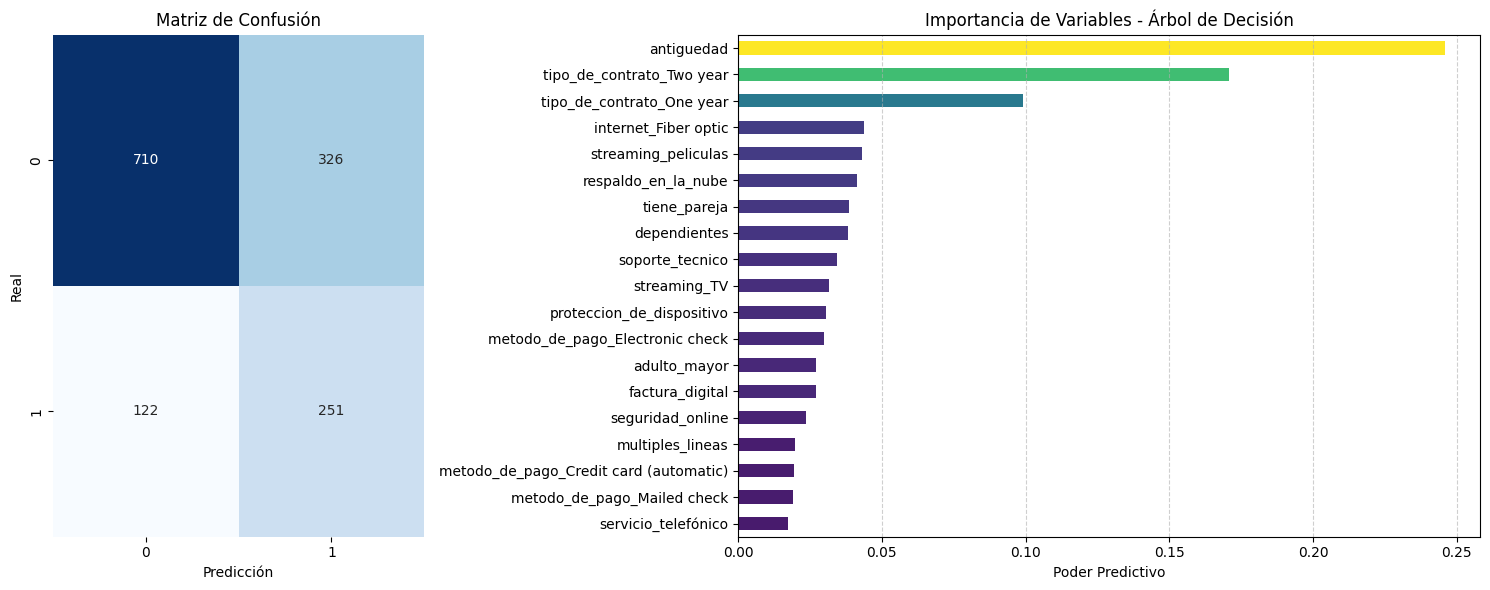

In [115]:
dt_model = DecisionTreeClassifier(random_state=42).fit(X_train_res, y_train_res)
model_report("Árbol de Decisión", dt_model, X_test, y_test)

###Random Forest


 REPORTE: Random Forest
              precision    recall  f1-score   support

           0       0.89      0.72      0.79      1036
           1       0.49      0.75      0.59       373

    accuracy                           0.73      1409
   macro avg       0.69      0.74      0.69      1409
weighted avg       0.78      0.73      0.74      1409



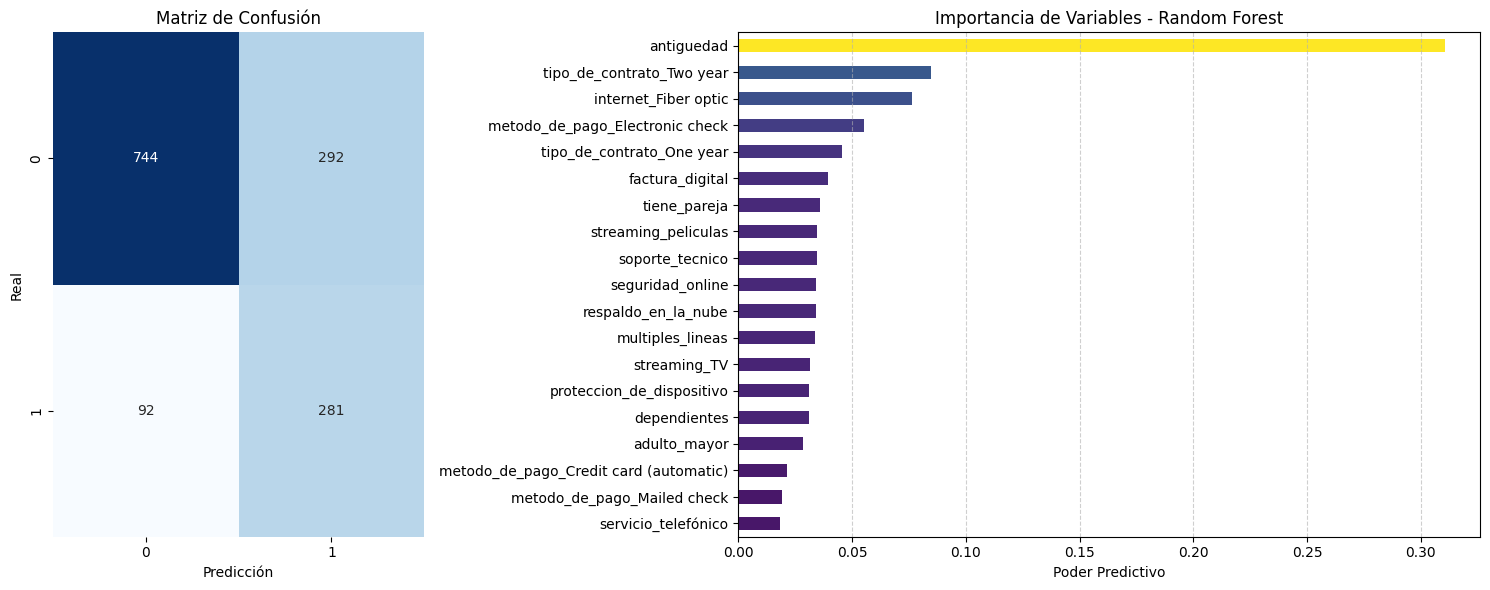

In [116]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42).fit(X_train_res, y_train_res)
model_report("Random Forest", rf_model, X_test, y_test)

##Evaluación de Modelos

### 1. Evaluación de Métricas Comparativas
Tras implementar el balanceo por **Random UnderSampler (RUS)**, estas son las métricas obtenidas para la clase crítica (**1 = Cancelación**):

| Modelo | Exactitud (Accuracy) | Precisión (Clase 1) | Recall (Clase 1) | F1-Score (Clase 1) |
| :--- | :---: | :---: | :---: | :---: |
| **Regresión Logística** | **0.74** | **0.51** | **0.78** | **0.62** |
| Random Forest | 0.73 | 0.49 | 0.75 | 0.59 |
| KNN | 0.69 | 0.44 | 0.70 | 0.54 |
| Árbol de Decisión | 0.68 | 0.44 | 0.67 | 0.53 |

#### 🔍 Análisis de Matrices de Confusión
* **Regresión Logística:** Logra capturar **291 fugas reales** de 373 totales, con solo 82 falsos negativos. Es el modelo que más clientes en riesgo detecta.
* **Random Forest:** Detecta **281 fugas**, manteniendo un desempeño muy equilibrado.
* **Árbol de Decisión:** Captura **251 fugas**, siendo el menos eficiente en términos de volumen de detección.

---

### 2. Análisis Crítico y Comparación

#### Modelo con  mejor desempeño
 La Regresión Logística es el modelo que supera a los demás en todas las métricas clave para la clase de interés: tiene el **Recall más alto (0.78)** y el mejor **F1-score (0.62)**. Esto significa que es la herramienta más eficaz para identificar proactivamente a los clientes que planean abandonar el servicio, minimizando las pérdidas económicas por deserción.

#### 📉 Diagnóstico de Overfitting y Underfitting

##### **Regresión Logística y Random Forest: Generalización Óptima**
Ambos modelos presentan un rendimiento sólido y equilibrado. **No hay evidencia de overfitting**, ya que las métricas en el set de prueba son consistentes y realistas para un problema de comportamiento humano. El uso de RUS ayudó a estos modelos a enfocarse en los rasgos distintivos de la cancelación sin "memorizar" el ruido de la clase mayoritaria.

##### **Árbol de Decisión y KNN: Riesgo de Underfitting**
* **Diagnóstico:** Estos modelos presentan señales de **underfitting** (subajuste).
* **Causa:** El Árbol de Decisión muestra el Recall y Precisión más bajos. Indica que el modelo es demasiado simple para capturar la complejidad de los datos.

---

### 3. Drivers de Cancelación (Insights de Negocio)
Al observar la importancia de variables, ambos modelos coinciden en que la **antigüedad** y el **tipo de contrato** son los factores determinantes.

 **Conclusión:** El problema es de **retención temprana**. Los clientes con contratos mes a mes y poca antigüedad son el segmento de mayor riesgo.

#📋 Interpretación y Conclusiones

##Análisis de la Importancia de las Variables

#### 1. Regresión Logística: Análisis de Coeficientes
En este modelo, la relevancia se determina por el peso (**coeficiente**) asignado a cada variable tras la normalización.

* **Funcionamiento:** Los coeficientes indican cuánto cambia la probabilidad de cancelación ante un aumento unitario en la variable.
* **Hallazgo:** Al haber obtenido el mejor **F1-Score (0.62)**, sus coeficientes son los más confiables.
    * **Positivos altos:** (Ej. métodos de pago específicos o tipos de internet) aumentan el riesgo de fuga.
    * **Negativos:** (Ej. contratos a largo plazo) reducen el riesgo.

#### 2. Random Forest: Importancia por Reducción de Impureza
Este modelo calcula la importancia basándose en cuánto ayuda cada variable a "limpiar" o separar las clases en cada división de los árboles (**Gini Importance**).

* **Variable Crítica:** La **antigüedad (tenure)** es el predictor más fuerte.
* **Interpretación:** El modelo identifica que las primeras divisiones de los árboles ocurren casi siempre en la antigüedad, lo que maximiza la ganancia de información para detectar quién se queda y quién se va.

### 3. Árbol de Decisión: Jerarquía de Decisiones
A diferencia del bosque, el árbol es más "radical" y jerárquico en su selección de variables.

* **Comportamiento:** El árbol concentra mucha importancia en el **tipo de contrato** y la **antigüedad**.
* **Impacto:** Si una variable es capaz de separar un gran grupo de clientes de una sola vez, el árbol le asigna un peso dominante. Esto explica por qué el gráfico muestra barras muy altas para los primeros factores y casi nulas para el resto.

### 4. KNN (K-Nearest Neighbors): Influencia por Proximidad
A diferencia de los anteriores, KNN no entrega un "ranking" de importancia explícito porque es un modelo basado en instancias (puntos en el espacio).

* **Mecánica:** La relevancia es implícita y depende totalmente de la **distancia euclidiana**.
* **Importancia de la Normalización:** Gracias a que normalizamos los datos, variables con rangos grandes (como el gasto total) no dominan sobre las pequeñas. Los "vecinos" se definen por la similitud en todo el conjunto de características.

---

## 💡 Conclusión sobre la Relevancia
Existe un **consenso entre los modelos** de que la **antigüedad** y el **tipo de contrato** son los pilares de la predicción.

**Validación:** Esto confirma el análisis exploratorio inicial (EDA), donde el boxplot ya mostraba una diferencia drástica en la mediana de meses entre los clientes que cancelan y los que permanecen.

##Conclusión

## 1. Rendimiento de los Modelos y Selección Final

Tras evaluar cuatro arquitecturas utilizando la técnica de balanceo **Random UnderSampler (RUS)**, se obtuvieron los siguientes resultados en el conjunto de prueba:

| Modelo | Accuracy | Precisión (Clase 1) | Recall (Clase 1) | F1-Score (Clase 1) |
| :--- | :---: | :---: | :---: | :---: |
| **Regresión Logística** | **0.74** | **0.51** | **0.78** | **0.62** |
| Random Forest | 0.73 | 0.49 | 0.75 | 0.59 |
| KNN | 0.69 | 0.44 | 0.70 | 0.54 |
| Árbol de Decisión | 0.68 | 0.44 | 0.67 | 0.53 |

> **🏆 Selección Final:** El modelo elegido es la **Regresión Logística**. Presenta el **Recall más alto (0.78)**, lo que permite identificar correctamente al 78% de los clientes en riesgo real. Su **F1-Score de 0.62** lo posiciona como la herramienta más robusta y equilibrada.

---

## 2. Factores Determinantes de la Cancelación (Drivers)

A través del análisis de importancia de variables y el EDA, se identificaron los siguientes impulsores críticos:

* **Antigüedad:** Factor más influyente. Existe una "zona crítica" en los primeros **10 a 12 meses**. Si el cliente supera los dos años, la probabilidad de fuga disminuye drásticamente.
* **Tipo de Contrato:** Los contratos **"Mes a Mes"** presentan una tasa de cancelación significativamente superior a los contratos de largo plazo.
* **Servicio de Internet:** La **Fibra Óptica** aparece como un factor de riesgo, sugiriendo posible insatisfacción.
* **Método de Pago:** Clientes con **"Electronic Check"** muestran mayor tendencia a la cancelación en comparación con pagos automáticos.

---

## 3. Estrategias de Retención Propuestas 🚀

Basándonos en los hallazgos del modelo, se proponen las siguientes acciones comerciales:

### A. Programa de "Aterrizaje Seguro"
* **Acción:** Campañas de contacto proactivo y beneficios exclusivos durante los **primeros 6 meses**.
* **Justificación:** El riesgo máximo se concentra en clientes nuevos (Baja antigüedad).

### B. Incentivos de Migración de Contrato
* **Acción:** Ofrecer descuentos o *upgrades* para migrar de planes mensuales a planes de **1 o 2 años**.
* **Justificación:** El contrato es el segundo factor de mayor peso en la predicción.

### C. Auditoría del Servicio de Fibra Óptica
* **Acción:** Encuestas de satisfacción específicas y revisión de competitividad de precios en este segmento.
* **Justificación:** El modelo lo identifica como un *driver* relevante de abandono.

### D. Automatización de Pagos
* **Acción:** Promover el cambio de cheque electrónico a **débito automático** mediante bonificaciones únicas.
* **Justificación:** Los métodos automáticos están asociados a una mayor lealtad.